In [ ]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [17]:
# ---------------------------------------
# paths
# ---------------------------------------
n_best=2572
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D.nc")
best1=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo1D.nc")
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)
obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
ref=xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_BOX2013_monthly_t2m-1981-2010-pr-1850-2000-corr-all.nc")
temps1 = xr.open_dataset("/p/projects/megarun/luciagu/data/HadCRUT5/HadCRUT.5.0.0.0_analysis_summary-series_global_annual.nc")
temps2 = xr.open_dataset("/p/projects/megarun/luciagu/data/HadCRUT5/HadCRUT.5.0.0.0_analysis_component-series_global_annual.nc")
dist=xr.open_dataset("../output/HTM_distances.nc")



In [18]:

def plot_temp(ax, best, lapse_rate= 0.0065):
    ta_sea_level = best.Ta_sum + (lapse_rate * best.z_srf)
    htm = ta_sea_level.sel(time=slice(-10000, -6000)).mean(axis=0)
    pday = ta_sea_level.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values
    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-4,4,21),cmap="Spectral_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)
    print(anom.mean(axis=0).mean(axis=0))
    ax.text(750,-800,"(a)")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im, anom

def plot_precip(ax, best, lapse_rate= 0):
    ta_sea_level = best.Pr_ann + (lapse_rate * best.z_srf)
    htm = ta_sea_level.sel(time=slice(-10000, -6000)).mean(axis=0)
    pday = ta_sea_level.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values

    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-0.6,0.6,21),cmap="PiYG_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)

    ax.text(750,-800,"(b)")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im


def plot_thick(ax,best,minimal):
    if minimal == 0:
        htm = best.H_ice.sel(time=slice(-10000, -6000)).mean(axis=0)
        label="(c)"
    else:
        htm = best.H_ice.sel(time=-4800)
        label="(d)"
    pday = best.H_ice.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values

    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-1000,1000,21),cmap="bwr_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)
    cs1 = ax.contour(htm.xc, htm.yc, pday, levels=np.linspace(0, 10, 1), colors='gray',linewidths=1)
    cs1 = ax.contour(htm.xc, htm.yc, htm, levels=np.linspace(0, 10, 1), colors='black',linewidths=1)

    ax.text(750,-800,label)
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im

In [19]:
sim0=best
# Kangerlussuaq Fjord
lat = 67.0050
lon = -50.6931
dist = np.sqrt((sim0.lat2D - lat)**2 + (sim0.lon2D - lon)**2)
iy, ix = np.unravel_index(dist.argmin(), dist.shape)
xc_k = sim0.isel(yc=iy, xc=ix).xc.values
yc_k = sim0.isel(yc=iy, xc=ix).yc.values

# 79º north glacier
lat = 79.0000
lon = -25.0000
dist = np.sqrt((sim0.lat2D - lat)**2 + (sim0.lon2D - lon)**2)
iy, ix = np.unravel_index(dist.argmin(), dist.shape)
xc_79 = sim0.isel(yc=iy, xc=ix).xc.values
yc_79 = sim0.isel(yc=iy, xc=ix).yc.values

<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\D'
<>:63: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_228154/3957589382.py:26: SyntaxWarning: invalid escape sequence '\c'
  ax1.text(xc_79-300, yc_79-100, "79$^{\circ}$N", fontsize=9)
/tmp/ipykernel_228154/3957589382.py:41: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{T_{JJA}}$ $^{\circ}\mathrm{C}$')
/tmp/ipykernel_228154/3957589382.py:52: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{P_{ann}}$ (m/a w.e.)')
/tmp/ipykernel_228154/3957589382.py:63: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{H_{ice}}$ (m)')


2.1755211


/tmp/ipykernel_228154/3957589382.py:34: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,
/tmp/ipykernel_228154/3957589382.py:45: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,


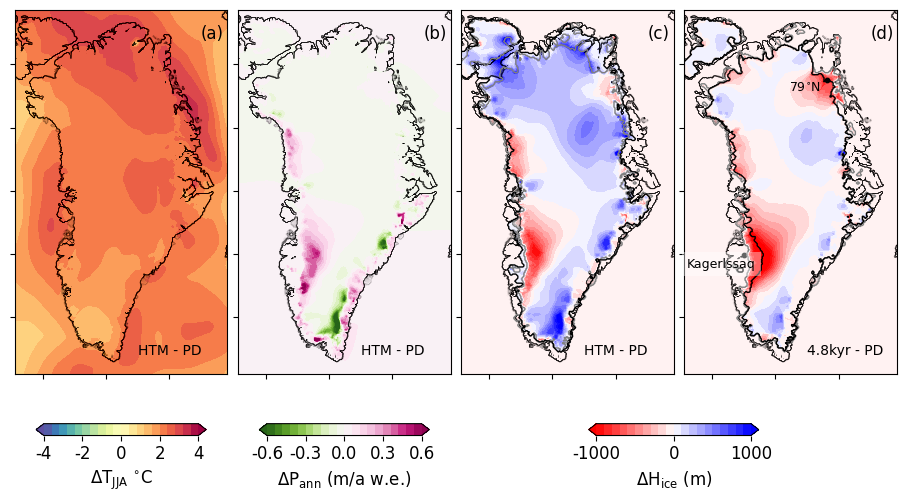

In [ ]:
fig = plt.figure(figsize=(9, 5))

gs = gridspec.GridSpec(2, 4,height_ratios=[7, 1])
#  H_ice ---------------------------------------------------------------------
ax1 = plt.subplot(gs[0, 0])
im1,anom_htm_pd = plot_temp(ax1, best, lapse_rate= 0.0065)
ax1.text(250,-3300,"HTM - PD",fontsize=10, horizontalalignment="left")

ax1 = plt.subplot(gs[0, 1])
im2 = plot_precip(ax1, best, lapse_rate= 0)
ax1.text(250,-3300,"HTM - PD",fontsize=10, horizontalalignment="left")

ax1 = plt.subplot(gs[0, 2])
im3 = plot_thick(ax1,best,0)
ax1.text(250,-3300,"HTM - PD",fontsize=10, horizontalalignment="left")

ax1 = plt.subplot(gs[0, 3])
im4 = plot_thick(ax1,best,1)
ax1.text(250,-3300,"4.8kyr - PD",fontsize=10, horizontalalignment="left")

ax1.scatter(xc_k, yc_k, color="black", edgecolor="black", s=10)
ax1.scatter(xc_79, yc_79, color="black", edgecolor="black", s=10)

ax1.text(xc_k-450, yc_k+-100, "Kagerlssaq", fontsize=9,
         bbox=dict(facecolor='white', alpha=0.4, edgecolor='none'))
ax1.text(xc_79-300, yc_79-100, "79$^{\circ}$N", fontsize=9)

# Legend and colorbars ------------------------------------------------------

# Leyenda

ax4 = plt.subplot(gs[1, 0])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(im1, cax=axins, orientation='horizontal',ticks=[-4,-2,0,2,4])
cb.set_label('$\Delta \mathrm{T_{JJA}}$ $^{\circ}\mathrm{C}$')

ax4 = plt.subplot(gs[1, 1])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(im2, cax=axins, orientation='horizontal',ticks=[-0.6,-0.3,0,0.3,0.6])
cb.set_label('$\Delta \mathrm{P_{ann}}$ (m/a w.e.)')

ax4 = plt.subplot(gs[1, 2:3])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0,bbox_to_anchor=(0.5, 0.0, 1.0, 1.0),)
cb = plt.colorbar(im3, cax=axins, orientation='horizontal',ticks=[-1000,0,1000])
cb.set_label('$\Delta \mathrm{H_{ice}}$ (m)')

plt.subplots_adjust(left=0.01, right=0.99, top=1,   bottom=0.05, wspace=0.05,  hspace=0)
plt.savefig(f"../figs_final/fig7_{n_best}_htm_diffs.pdf",dpi=300)
plt.close()


In [21]:
from scipy.optimize import curve_fit

ts = xr.open_dataset("../output/HTM_ens.nc")
scores = xr.open_dataset("../scoring/scores/scores_final.nc")
dist=xr.open_dataset("../output/HTM_distances.nc")

colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.3, 1.0]
my_cmap = mcolors.LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))

x = dist.d_kan.values
y = -ts.dV_sle.values
s = scores.S.values*1e2
z_order = np.argsort(s)
s = s[z_order]
norm = mcolors.Normalize(vmin=s.min(), vmax=s.max())

x = x[z_order]
y = y[z_order]
sigma_puntos = 1 / np.sqrt(s)

def modelo_2(x, a, b, c):
    return a*x**2 + b*x + c

popt_w, pcov_w = curve_fit(modelo_2, x, y, sigma=sigma_puntos, absolute_sigma=True)
popt_ols, pcov_ols = curve_fit(modelo_2, x, y, absolute_sigma=True)

err_w = np.sqrt(np.diag(pcov_w))
err_ols = np.sqrt(np.diag(pcov_ols))

x_fit = np.linspace(0, x.max(), 100)


Weighted fit: (0.000017 ± 0.000224)$x^2$ + (0.0008 ± 0.0644)$x$ + (0.2885 ± 4.6070)
Unweighted fit: (0.000008 ± 0.000014)$x^2$ + (0.0024 ± 0.0035)$x$ + (0.2551 ± 0.2141)


<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_228154/2219338072.py:21: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$GMSL (m)')


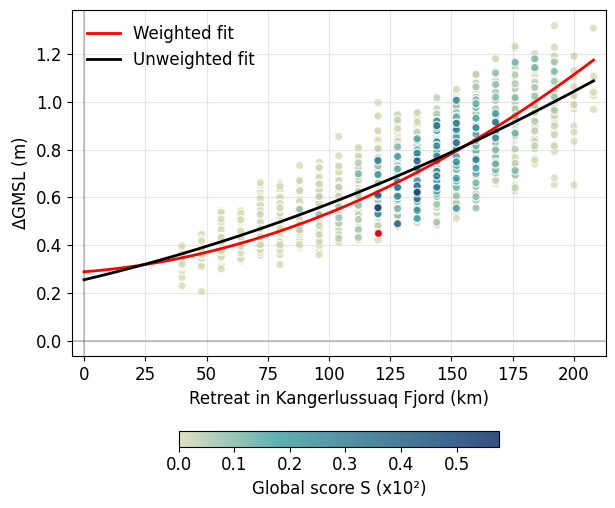

In [ ]:

fig, (ax) = plt.subplots(1, 1, figsize=(6, 5), sharey=True)

current_x, label =x, 'Kangerlussuaq Fjord'

scatter = ax.scatter(current_x, y, c=s, cmap=my_cmap, norm=norm, edgecolors='w', alpha=0.8)
ax.scatter(current_x[-1],y[-1], c="red", edgecolors='w', alpha=0.8)
ax.plot(x_fit, modelo_2(x_fit, *popt_w), color='red', lw=2, 
        label=f'Weighted fit')

ax.plot(x_fit, modelo_2(x_fit, *popt_ols), color='black', lw=2, linestyle='-',
        label=f'Unweighted fit')

ax.axvline(x=0,color="black",alpha=0.2)
ax.axhline(y=0,color="black",alpha=0.2)
ax.legend(loc='upper left', frameon=False)
ax.set_xlabel(f'Retreat in {label} (km)')
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-5,current_x.max()+5)


ax.set_ylabel('$\Delta$GMSL (m)')
cbar = fig.colorbar(scatter, ax=ax, location='bottom', aspect=20, shrink=0.6,pad=0.15)
cbar.set_label('Global score S (x10²)')
fig.tight_layout()
plt.subplots_adjust(left=0.1, right=0.99, top=0.99, bottom=0)

print(f'Weighted fit: ({popt_w[0]:.6f} ± {err_w[0]:.6f})$x^2$ + ({popt_w[1]:.4f} ± {err_w[1]:.4f})$x$ + ({popt_w[2]:.4f} ± {err_w[2]:.4f})')
print(f'Unweighted fit: ({popt_ols[0]:.6f} ± {err_ols[0]:.6f})$x^2$ + ({popt_ols[1]:.4f} ± {err_ols[1]:.4f})$x$ + ({popt_ols[2]:.4f} ± {err_ols[2]:.4f})')

plt.show()
fig.savefig(f"../figs_final/fig15_{n_best}htm_fit.pdf", dpi=300)